In [29]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt
import os,sys
from pathlib import Path

# # NOTE: My .py files
# from standardizing_data import (
#     standardize_lc,normalize_standardized_lc,_apply_quality_mask,
#     get_tess_lc,
#     _get_colors,
#     collect_lightcurves_for_target,
#     # constants
#     DEFAULT_RADIUS,
#     DEFAULT_CADENCE,
#     DEFAULT_DOWNLOADPATH
# )


# from phasefold import phasefold, plot_phasefolded
# from astropy.stats import sigma_clip


from Full_HLSP_and_NEMESIS_Comparison_pipeline import run_batch

# Read in Catalog

In [3]:
catalog_dir = (Path.cwd() / "../Catalog/").resolve()

nearby_TOI_MD_df=pd.read_csv(f'{catalog_dir}/nearby_TOI_MDs.csv')
nearby_TOI_MD_df.head(5)

,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn
0,0,spoc-s01-s36-b0A-CPKP,SPOC,410153553,136.01,PC,340.492100,-69.169000,340.496204,-69.172108,11.877,0.064,1325.724661,0.000156,0.462931,3.872269e-06,0.631015,0.022202,4677.673602,171.681260,"1,27,28,67,68,94,95,101,102,103,104",LHS 3844 b,5.09707,0.426694,1,0.188624,0.005710,1.517197,0.061800,723.372047,3043.0,63.0,64.709477,38.885654,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2020-10-27 13:01:47.547000+00:00,410153553,340.492156,-69.168978,334.3570,-726.9740,11.92380,STAR,tmgaia2,20190415,NaN,NaN,105-116381,22415815-6910089,NaN,NaN,6385548541499112448,33464847.0,NaN,tmgaia2,0.082820,0.086335,gaia2,67.15480,0.050599,gaia2,318.253844,-43.907555,304.887051,-54.122569,16.942,0.041,15.240,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.046,0.023,9.477,0.023,9.145,0.023,AAA-222-111-000-0-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.3925,0.000738,0.007698,cdwrf,cdwrf,3004.0,157.0,5.08528,0.029186,NaN,NaN,0.188624,0.005710,0.157909,0.020067,23.52970,0.863072,DWARF,0.002610,0.000708,14.8846,0.0113,0.000000,0.000000,81.0,0.010833,NaN,NaN,0.009687,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0113,0.0113,bj2018,NaN,NaN,cdwrf,15.4512,0.007263,12.05170,0.002827,1,NaN,cdwrf,apassdr9,cooldwarfs_v8,1.559812,1.338867,340.496204,-69.172108,0.041207,0.042399,1,0,0.0,0.1933,0.5347,1.570796,2.913518,8.243782,328.631928,NaN,8.866874e+07,64.915025,11.0,"3,3,3,2,2,2,2,4,4,3,3","2,1,2,2,1,2,1,3,2,3,2","0,0,0,0,0,0,0,0,0,0,0"
1,1,spoc-s01-s69-b0A-CP,SPOC/QLP,234994474,134.01,CP,350.031300,-60.065200,350.028592,-60.065729,9.169,0.019,1326.034032,0.000566,1.401518,4.810232e-06,1.158306,0.325507,593.754092,42.808456,"1,28,68,95,102,104,105",L 168-9 b,4.67812,0.063226,1,0.597007,0.018150,1.461685,1.838503,891.638989,3794.0,69.0,149.374754,20.450527,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2024-09-30 23:32:46.016000+00:00,234994474,350.031352,-60.065179,-319.9610,-127.7810,9.22978,STAR,tmgaia2,20190415,115211.0,9126-00748-1,150-224713,23200751-6003545,NaN,NaN,6491962296196145664,31785853.0,NaN,tmgaia2,0.102122,0.115073,gaia2,39.73310,0.037526,gaia2,321.954596,-53.560374,319.217901,-49.527946,12.460,0.025,11.005,0.018,Na

# Filter again for what is detectable

In [4]:
# Filter again for what is detectable

df = nearby_TOI_MD_df.copy()

mask = (
    (df["Transit Depth Value"]/1e6 >= 1000/1e6) &
    (df["Transit Duration (hours) Value"] >= 0.75) &
    (df["Sectors_Observed"] >= 2) &
    (df["Centroid Offset"].isna() | (df["Centroid Offset"] == 0)) &
    (df["TOI Disposition"].isin(["PC", "KP", "CP"])) &
    (df["contratio"] <= 0.1) &
    (df["Orbital Period (days) Value"] >= 0.5)
)
filtered_df = df[mask].copy()
print(f"{mask.sum()} / {len(df)} targets pass ({100*mask.mean():.1f}%)")

filtered_df.head(5)

225 / 471 targets pass (47.8%)


,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn
3,3,spoc-s01-s69-b0A-CP,SPOC,231702397,122.01,CP,332.947000,-58.945100,332.948236,-58.946085,13.048,0.040,1329.118988,0.000866,5.078033,0.000008,1.210035,0.277774,5923.128307,429.03534,"1,27,28,67,68,95,102,103,104,105",TOI-122 b,4.95810,0.407256,1,0.334125,0.010041,2.634776,0.682486,431.253644,3318.0,64.0,8.174314,15.281929,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2024-09-09 12:03:05.974000+00:00,231702397,332.947083,-58.945070,138.1380,-235.8100,13.08400,STAR,tmgaia2,20190415,NaN,NaN,156-214844,22114728-5856422,NaN,J221147.48-585644.6,6411096106487783296,29684102.0,NaN,tmgaia2,0.089206,0.075824,gaia2,16.06980,0.055510,gaia2,332.558568,-47.968575,309.565383,-43.840723,17.061,0.054,15.526,0.026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.531,0.024,11.020,0.022,10.771,0.021,AAA-222-111-000-0-0,NaN,10.640,0.022,10.455,0.021,10.259,0.068,9.185,NaN,14.3357,0.000442,0.007326,cdwrf,cdwrf,3356.0,157.0,4.88974,0.001773,NaN,NaN,0.334125,0.010041,0.315858,0.020251,8.46769,0.219840,DWARF,0.012759,0.003172,62.1180,0.21580,0.000000,0.000000,69.0,0.008771,NaN,NaN,0.001788,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2151,0.2165,bj2018,NaN,NaN,cdwrf,15.7971,0.002184,13.15230,0.001320,1,NaN,cdwrf,apassdr9,cooldwarfs_v8,1.588664,1.175990,332.948236,-58.946085,0.036728,0.041307,1,0,0.0,0.1555,0.4459,1.570796,7.436723,5.965413,64.654340,NaN,1.120091e+07,8.200268,10.0,"2,2,2,2,2,2,4,3,2,2","1,2,1,2,1,1,1,4,2,4","0,0,0,0,0,0,0,0,0,0"
4,4,spoc-s01-s36-b0A-CPKP,SPOC,234523599,127.01,CP,15.551099,-61.756001,15.551889,-61.756133,14.097,0.018,1325.650603,0.000243,3.795518,0.000002,2.019813,0.031575,52278.994098,560.41890,"1,2,28,29,68,69,95,96,103,104",HATS-71 b,4.43800,0.000000,1,0.445372,0.013560,10.326162,0.330784,525.943113,3424.0,0.0,18.083234,75.709694,False,5,5,5,5,5,5,5,2018-11-14 15:06:55+00:00,2021-12-09 10:32:02.109000+00:00,234523599,15.551172,-61.756017,78.8583,-27.0947,14.12660,STAR,tmgaia2,20190415,NaN,NaN,142-001044,01021226-6145216,NaN,J010212.39-614521.9,4710594412266148352,29743197.0,NaN,tmgaia2,0.086794,0.063901,gaia2,7.10286,0.043398,gaia2,300.693210,-55.325410,332.828534,-59.172473,17.217,0.180,1

In [5]:
PIPELINES=["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]#,'NEMESIS']

# Single target test

In [6]:

# # ─────────────────────────────────────────────────────────────────────────────
# # 3. Full batch: NEMESIS + HLSPs + LEO-Vetter, all available sectors
# # ─────────────────────────────────────────────────────────────────────────────
# manifest = run_batch(nearby_TOI_MD_df.iloc[2:3], 
#                      pipelines=PIPELINES,
#                      force_rerun=True, 
#                      nemesis_settings={"keep_FITS": True, "verbose":True})



# # ─────────────────────────────────────────────────────────────────────────────
# # 5. Post-batch: load and inspect outputs
# # ─────────────────────────────────────────────────────────────────────────────
# from pathlib import Path
# from standardizing_data import DEFAULT_DOWNLOADPATH

# saved_root = Path(DEFAULT_DOWNLOADPATH) / "batch_results" / "saved_results"

# # Reload the stacked catalog for one target
# tic_id     = int(nearby_TOI_MD_df.iloc[2]["TIC ID"])
# target_dirs = sorted(saved_root.glob(f"TIC{tic_id}_S[0-9][0-9][0-9][0-9]*"))
# if not target_dirs:
#     print(f"No V5 output directory found for TIC {tic_id}")
# else:
#     target_dir = target_dirs[-1]   # latest if multiple
#     cats = list(target_dir.glob("*_leovetter_catalog.parquet"))
#     if cats:
#         cat = pd.read_parquet(cats[0])
#         print(cat[["pipeline"] + [c for c in cat.columns if "LEOVetter_MES" in c]])
#     else:
#         print(sorted(f.name for f in target_dir.iterdir()))

# set up cache

In [7]:
# ── Step 0: cache + quaternion prefetch ───────────────────────────────────
from NEMESIS_pipeline_new_temp_4 import default_NEMESIS_pipeline_settings, prefetch_quaternions
from typing import Any, Dict, List, Optional, Union
def setup_cache(
    base_root: str,
    sectors: list[int],
    cache_dir: Optional[str] = None,
    quat_dir: Optional[str] = None,
    verbose: bool = True,
) -> dict:
    """
    Create (or point to existing) cache/quaternion directories and prefetch
    quaternions.  Call once per session — or once per period group if each
    group has its own pre-existing cache.

    Parameters
    ----------
    base_root : root directory for the recovery run.  Used to build default
                paths when cache_dir / quat_dir are not provided.
    sectors   : TESS sector integers to prefetch (e.g. list(range(1, 27))).
    cache_dir : optional path to an existing FITS cache directory
                (downloadpath + cache_dir_path).  If None, defaults to
                base_root/cache/.
    quat_dir  : optional path to an existing quaternion directory.  If None,
                resolved via _resolve_quat_savepath (which typically places
                it inside cache_dir).  Pass explicitly when quaternions
                already live elsewhere, e.g. os.getcwd() + '/cache/quaternions/'.
    verbose   : passed to prefetch_quaternions.

    Returns
    -------
    shared : dict with keys
        'cache_dir'    – absolute path to the FITS cache directory in use
        'quat_savepath'– absolute path to the quaternion directory in use
        'quat_status'  – per-sector status dict from prefetch_quaternions

    Examples
    --------
    # Fully default — build everything under base_root/cache/
    shared = setup_cache(BASE_OUT, list(range(1, 27)))

    # Re-use existing FITS cache; let quat path resolve automatically
    shared_short = setup_cache(BASE_OUT, list(range(1, 27)),
                               cache_dir=shortPerpath + 'cache/')

    # Re-use both existing caches explicitly
    shared = setup_cache(BASE_OUT, list(range(1, 27)),
                         cache_dir=os.getcwd() + '/cache/',
                         quat_dir =os.getcwd() + '/cache/quaternions/')
    """
    if cache_dir is None:
        cache_dir = os.path.join(base_root, 'cache', '')
    cache_dir = os.path.join(cache_dir, '')   # ensure trailing separator
    os.makedirs(cache_dir, exist_ok=True)

    settings = default_NEMESIS_pipeline_settings()
    settings['cache_dir_path'] = cache_dir
    settings['downloadpath']   = cache_dir
    settings['verbose']        = verbose

    if quat_dir is not None:
        quat_savepath = os.path.join(quat_dir, '')
    else:
        quat_savepath = _resolve_quat_savepath(settings)
    os.makedirs(quat_savepath, exist_ok=True)

    # write resolved path back into settings so prefetch_quaternions
    # and any internal _resolve_quat_savepath calls use the correct location
    settings['quat_savepath'] = quat_savepath

    if verbose:
        print(f'[setup_cache] cache_dir    : {cache_dir}')
        print(f'[setup_cache] quat_savepath: {quat_savepath}')

    quat_status = prefetch_quaternions(sectors, settings, verbose=verbose)

    return dict(
        cache_dir     = cache_dir,
        quat_savepath = quat_savepath,
        quat_status   = quat_status,
    )


def make_settings(
    project_path: str,
    shared: dict,
) -> dict:
    """
    Build a NEMESIS settings dict for one (scenario, project_path) combination.
    Per-target overrides (maxP, N_transits) are applied inside run_one_target.

    Parameters
    ----------
    project_path : scenario-level output directory, e.g.
                   'TOI_short_period/test_a/'  NEMESIS writes Sector_XXXX/
                   subdirectories here.
    scenario     : 'a', 'b', 'c', or 'd'
    shared       : dict from setup_cache

    Returns
    -------
    settings dict — copy of pipeline defaults with scenario + path overrides applied
    """
    s = dict(default_NEMESIS_pipeline_settings())

    s['base_path']      = project_path
    s['downloadpath']   = shared['cache_dir']
    s['cache_dir_path'] = shared['cache_dir']
    s['quat_savepath']  = shared['quat_savepath']  # always explicit; never re-derived
    s['verbose'] = True

    return s

In [8]:


RESULTS_ROOT = "/Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/"

all_sectors  = list(range(1, 27))

shared = setup_cache(
    RESULTS_ROOT, all_sectors,
    cache_dir = RESULTS_ROOT + 'cache/',
    quat_dir  = '/Users/daxfeliz/Desktop/TESS/NEMESIS_II/NEMESIS_II_Catalog_Recovery_Tests/cache/quaternions/',
)

# Build the settings dict carrying cache paths
nemesis_settings = make_settings(
    project_path = RESULTS_ROOT,   # base_path will be overridden per-target; that's fine
    shared       = shared,
)


nemesis_settings['keep_FITS']=True
nemesis_settings['verbose']=False

# # Smoke test
# manifest = run_batch(
#     nearby_TOI_MD_df.iloc[:3].reset_index(drop=True),
#     pipelines        = PIPELINES,
#     nemesis_settings = nemesis_settings,
#     verbose          = True,
# )

[setup_cache] cache_dir    : /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/cache/
[setup_cache] quat_savepath: /Users/daxfeliz/Desktop/TESS/NEMESIS_II/NEMESIS_II_Catalog_Recovery_Tests/cache/quaternions/
  [quat S01] already cached → sector_01_quaternion.fits
  [quat S02] already cached → sector_02_quaternion.fits
  [quat S03] already cached → sector_03_quaternion.fits
  [quat S04] already cached → sector_04_quaternion.fits
  [quat S05] already cached → sector_05_quaternion.fits
  [quat S06] already cached → sector_06_quaternion.fits
  [quat S07] already cached → sector_07_quaternion.fits
  [quat S08] already cached → sector_08_quaternion.fits
  [quat S09] already cached → sector_09_quaternion.fits
  [quat S10] already cached → sector_10_quaternion.fits
  [quat S11] already cached → sector_11_quaternion.fits
  [quat S12] already cached → sector_12_quaternion.fits
  [quat S13] already cached → sector_13_quaternion.fits
  [quat S14] already 

In [ ]:
nemesis_settings

# All targets

# See "Light_Curve_Extraction.pdf" for preview of pre-run files. I had to clear the output in the cell below in order to upload this notebook (was > 25MB)

In [35]:

# ─────────────────────────────────────────────────────────────────────────────
# 3. Full batch: NEMESIS + HLSPs + LEO-Vetter, all available sectors
# ─────────────────────────────────────────────────────────────────────────────




manifest = run_batch(
#     catalog_df = nearby_TOI_MD_df, 
    catalog_df = filtered_df,
    pipelines=PIPELINES,
    force_rerun=False,
    force_releovetter=True,
    refine_t0=False,
    nemesis_settings = nemesis_settings)





# For targets with obvious T0 drift (phasefolded LCs off by a few hours)

In [30]:
tics_with_T0_drift =[192833836, 111778581]

In [31]:
# example of how to filter by a TIC ID list
filtered_df[filtered_df['TIC ID'].isin(tics_with_T0_drift)]

,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn
468,468,spoc-s87-b02,CTOI,192833836,7384.01,PC,83.103441,-39.833811,83.103183,-39.834250,13.6940,0.007686,3668.525654,0.002568,6.233516,0.001406,1.517975,0.205676,13899.355597,1476.0515,"5,6,32,33,87,98",CTOI from Dax Felix,4.91063,0.003833,1,0.313932,0.009498,3.928667,0.404057,378.336117,3211.0,157.0,4.842083,5.773855,False,3,4,3,3,4,4,4,2025-04-10 23:13:18.825606+00:00,2025-04-10 22:43:01.200000+00:00,192833836,83.103441,-39.833811,-45.8651,-102.0140,13.6940,STAR,tmgaia2,20190415,NaN,NaN,251-006761,05322483-3950016,NaN,J053224.78-395002.7,4808732662634331520,NaN,NaN,tmgaia2,0.082975,0.102116,gaia2,14.94350,0.044063,gaia2,244.939838,-31.540120,78.284286,-62.992890,17.630,0.168,16.704,0.206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.001,0.026,11.382,0.026,11.096,0.023,AAA-222-111-000-0-0,NaN,10.942,0.023,10.779,0.021,10.551,0.064,8.940,NaN,15.0456,0.000847,0.007686,cdwrf,cdwrf,3211.0,157.0,4.91063,0.003833,NaN,NaN,0.313932,0.009498,0.292574,0.020259,9.45647,0.202550,DWARF,0.009439,0.002432,66.7902,0.19805,0.000000,0.00000,75.0,0.018910,NaN,NaN,0.001622,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1975,0.1986,bj2018,NaN,NaN,cdwrf,16.7259,0.009937,13.7850,0.002738,1,NaN,ucac4,bpbj,cooldwarfs_v8,1.368444,1.583467,83.103183,-39.834250,0.037249,0.046011,1,0,0.0,0.1533,0.4776,1.570796,14.653833,11.553185,88.443100,NaN,6.634894e+06,4.857454,6.0,"3,3,3,3,3,3","1,2,1,2,2,1","0,0,0,0,0,0"
470,470,spoc-s92-b02,CTOI,111778581,7494.01,PC,344.326323,-17.395348,344.326437,-17.395485,13.8727,0.007482,3804.362235,0.001374,11.421206,0.001865,2.306741,0.128388,41150.980909,1697.6941,"2,29,42,69,70,92,96",CTOI from Marco Montalto; Gaia DR3 RV error ~4 km/s,4.75533,0.007794,1,0.479589,0.014635,9.789783,0.489982,309.477982,3555.0,157.0,2.167904,26.503975,False,3,4,3,3,4,4,4,2025-09-03 20:59:11.092009+00:00,2025-09-03 20:02:20+00:00,111778581,344.326323,-17.395348,25.0872,-31.8466,13.8727,STAR,tmgaia2,20190415,NaN,NaN,364-185798,22571831-1723431,NaN,J225718.33-172343.6,2403356775631204352,10064835.0,NaN,tmgaia2,0.127764,0.084650,gaia2,6.72711,0.058093,gaia2,47.234016,-61.939725,338.849995,-9.889336,17.461,0.162,16.270,0

[batch] 2 targets total, 0 already done, 2 to run.  Mode: LEO-Vetter only (cached photometry, all targets).  LEO-Vetter enabled.
[1/2] TIC 192833836 -- running ...


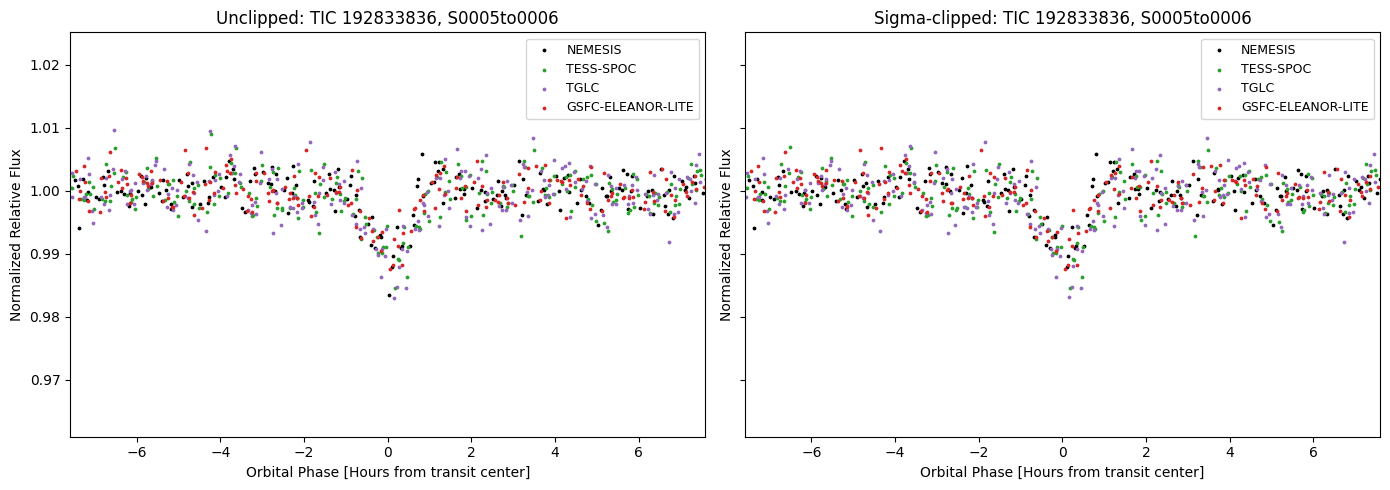

[1/2] TIC 192833836 -- DONE  (3.4s, sectors=S0005to0006, hlsp_ok=["TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"], nemesis=error)
[2/2] TIC 111778581 -- running ...


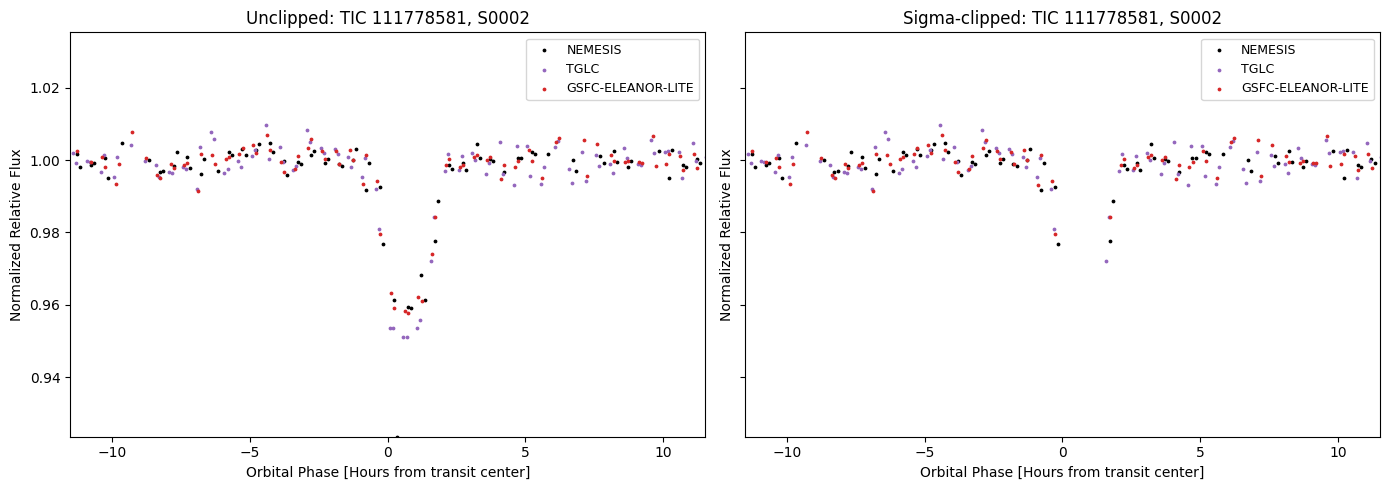

[2/2] TIC 111778581 -- DONE  (2.5s, sectors=S0002, hlsp_ok=["TGLC", "GSFC-ELEANOR-LITE"], nemesis=error)

[batch] Complete -- 220 done, 0 failed.
[batch] Manifest: /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/run_manifest.csv


In [32]:
manifest = run_batch(
    catalog_df = filtered_df[filtered_df['TIC ID'].isin(tics_with_T0_drift)],
    pipelines=PIPELINES,
    force_rerun=False,
    force_releovetter=True,
    refine_t0=True, #<--- this will attempt to correct T0
    nemesis_settings = nemesis_settings)





# To do: 
# View all phasefolded diagrams above, mark which ones have phase offsets and then rerun with refine_t0 = True. Keep force_rerun=False, and force_releovetter=True to used cached data and re-apply LEO-Vetter. This should take ~ 30-60 minutes on 225 targets.